In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import export_text

: 

In [8]:
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target
print(iris.feature_names)  # ['sepal length (cm)', 'sepal width (cm)', ...]
print(iris.target_names)   # ['setosa', 'versicolor', 'virginica']

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [9]:
x = iris.data[:, 2]
y = iris.target

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

In [12]:
clf = DecisionTreeClassifier()
clf.fit(x_train.reshape(-1, 1), y_train)

DecisionTreeClassifier()

In [14]:
y_pred = clf.predict(x_test.reshape(-1, 1))
print(accuracy_score(y_test, y_pred))

0.9333333333333333


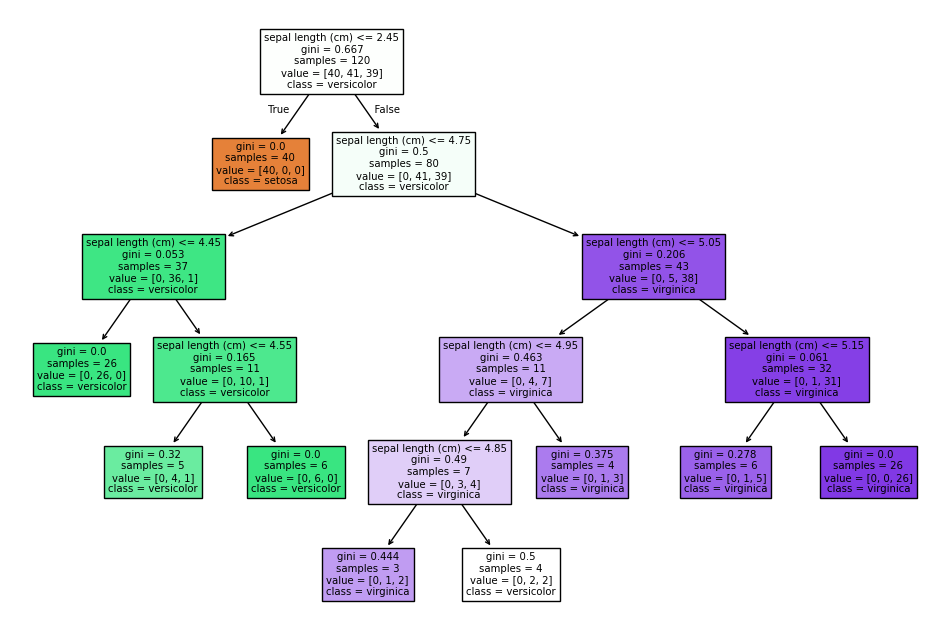

In [15]:
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=iris.feature_names[:2], class_names=iris.target_names)
plt.show()

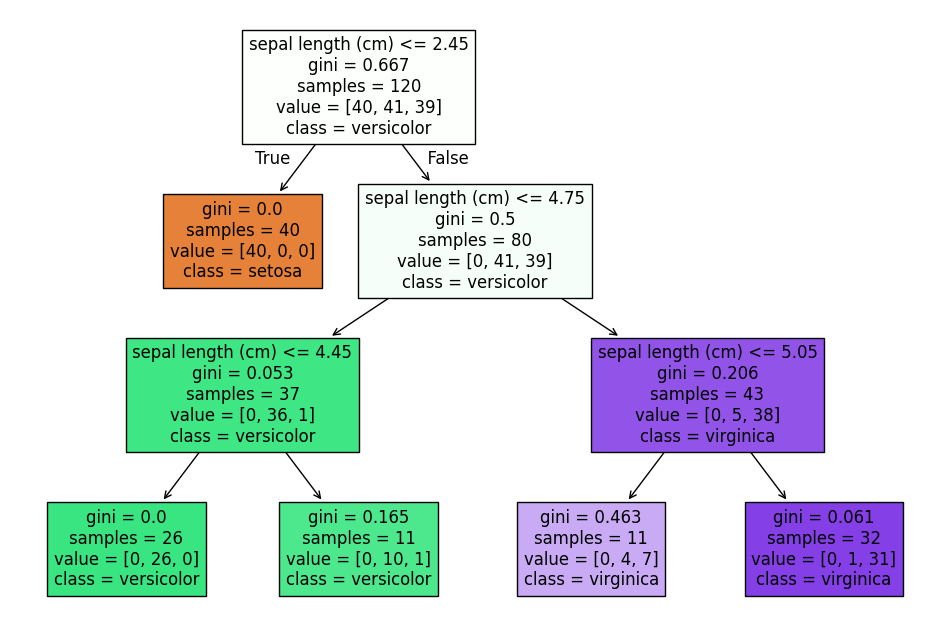

In [17]:
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(x_train.reshape(-1, 1), y_train)

plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=iris.feature_names[:2], class_names=iris.target_names)
plt.show()

In [23]:
r = export_text(clf, feature_names=['sepal length (cm)', 'sepal width (cm)'])
print(r)

ValueError: feature_names must contain 1 elements, got 2

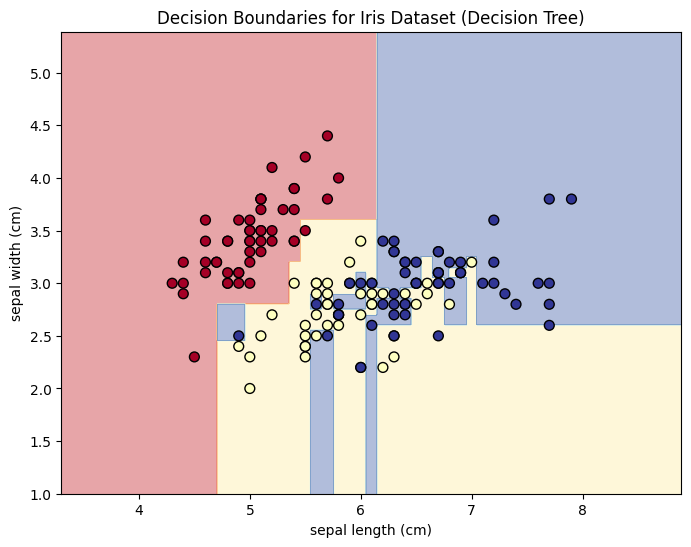

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Use only the first two features for visualization (sepal length, sepal width)
X = X[:, [0, 1]]  # Select sepal length (0) and sepal width (1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Create mesh grid for decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1  # Sepal length
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1  # Sepal width
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict on mesh grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')  # Color regions
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolor='k', cmap='RdYlBu')  # Data points
plt.xlabel(iris.feature_names[0])  # Sepal length
plt.ylabel(iris.feature_names[1])  # Sepal width
plt.title('Decision Boundaries for Iris Dataset (Decision Tree)')
plt.show()